# ABS 2021 Census POA: curation summary

This notebook reads the generated Census outputs using only relative paths. Run the Census pipeline before running this notebook.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

features = pd.read_csv('../results/census_clean.csv', dtype={'postcode': 'string'})
source_audit = pd.read_csv('../results/source_audit.csv')
with open('../results/census_metadata.json', encoding='utf-8') as handle:
    metadata = json.load(handle)

assert features.postcode.notna().all()
assert features.postcode.is_unique
assert features.postcode.str.fullmatch(r'[0-9]{4}').all()
assert not features.postcode.isin(['9494', '9797']).any()

display(pd.DataFrame({
    'measure': ['ordinary POAs', 'curated columns', 'Census year', 'consumer coverage', 'transaction enrichment'],
    'value': [len(features), len(features.columns), metadata['source_year'], metadata['consumer_join_status'], metadata['transaction_join_status']]
}))

,measure,value
0,ordinary POAs,2641
1,curated columns,59
2,Census year,2021
3,consumer coverage,completed_consumer_table_only
4,transaction enrichment,not_run


## Source and cleaning evidence

Seven ABS General Community Profile tables are used: G01 population and age, G02 median age/income/household size, G29 family structure, G33 income bands, G43 published rates and education, G46B labour-force counts, and G42 household structure. POA9494 and POA9797 are excluded from the ordinary postcode dimension and retained in the audit.

In [2]:
display(source_audit)

numeric_issues = pd.read_csv('../results/numeric_issues.csv')
ratio_issues = pd.read_csv('../results/ratio_issues.csv')
additivity = pd.read_csv('../results/additivity_checks.csv')

display(pd.DataFrame({
    'audit': ['source-cell issues', 'undefined or out-of-range derived ratios', 'non-additive published totals'],
    'records': [len(numeric_issues), len(ratio_issues), len(additivity)],
    'treatment': ['retain POA; set invalid cell to missing', 'retain source counts; set derived rate to missing', 'retain values; ABS perturbation can affect additivity']
}))

,source_table,raw_rows,accepted_rows,excluded_rows,invalid_key_rows,special_geography_rows,duplicate_keys,numeric_cells_set_null,source_missing_cells,source_non_numeric_cells,source_nonfinite_cells
0,G01,2643,2641,2,0,2,0,0,0,0,0
1,G02,2643,2641,2,0,2,0,5,0,0,0
2,G29,2643,2641,2,0,2,0,0,0,0,0
3,G33,2643,2641,2,0,2,0,0,0,0,0
4,G43,2643,2641,2,0,2,0,0,0,0,0
5,G46B,2643,2641,2,0,2,0,0,0,0,0
6,G42,2643,2641,2,0,2,0,0,0,0,0


,audit,records,treatment
0,source-cell issues,5,retain POA; set invalid cell to missing
1,undefined or out-of-range derived ratios,191,retain source counts; set derived rate to missing
2,non-additive published totals,7004,retain values; ABS perturbation can affect add...


## Added contextual features and rate comparison

The dimension includes age 20-44 count/share, households reporting weekly income of at least AUD 3,000, bachelor-degree count/share, and G43 published unemployment and labour-force-participation percentages. G46B count-derived percentages remain a quality-assurance comparison.

In [3]:
rate_comparison = pd.read_csv('../results/published_rate_comparison.csv')
display(rate_comparison.groupby(['measure', 'comparison_status'], dropna=False).agg(
    poas=('postcode', 'size'),
    median_absolute_difference_pp=('absolute_difference_pp', 'median'),
    maximum_absolute_difference_pp=('absolute_difference_pp', 'max')
).reset_index())

display(features[[
    'postcode', 'census_age_20_44_share', 'census_households_weekly_income_3000_plus_share',
    'census_bachelor_degree_share', 'census_unemployment_rate_published_pct',
    'census_labour_force_participation_rate_published_pct'
]].head())

,measure,comparison_status,poas,median_absolute_difference_pp,maximum_absolute_difference_pp
0,labour_force_participation_rate,both_available,2636,0.057191,50.0
1,labour_force_participation_rate,derived_missing,5,NaN,NaN
2,unemployment_rate,both_available,2639,0.060711,50.0
3,unemployment_rate,derived_missing,2,NaN,NaN


,postcode,census_age_20_44_share,census_households_weekly_income_3000_plus_share,census_bachelor_degree_share,census_unemployment_rate_published_pct,census_labour_force_participation_rate_published_pct
0,0800,0.607917,0.270442,0.252101,3.4,75.9
1,0810,0.412263,0.286930,0.209229,4.1,69.7
2,0812,0.333852,0.259701,0.140335,5.3,65.1
3,0820,0.455271,0.316449,0.229433,3.3,73.8
4,0822,0.395353,0.123658,0.041584,18.0,38.7


## Distribution and outlier review

The p99 threshold is an inspection flag only. Values are neither removed nor winsorised.

,field,nonmissing_rows,p99,flagged_rows,removed_rows,action
0,census_population,2641,64078.8,27,0,retain; upper-tail review only
1,census_median_age,2640,61.0,23,0,retain; upper-tail review only
2,census_median_household_income_weekly,2641,3176.6,27,0,retain; upper-tail review only
3,census_avg_household_size,2637,3.3,24,0,retain; upper-tail review only
4,census_age_20_44_count,2641,21652.0,27,0,retain; upper-tail review only
5,census_households_weekly_income_3000_plus_count,2641,5335.2,27,0,retain; upper-tail review only
6,census_bachelor_degree_count,2641,9078.8,27,0,retain; upper-tail review only


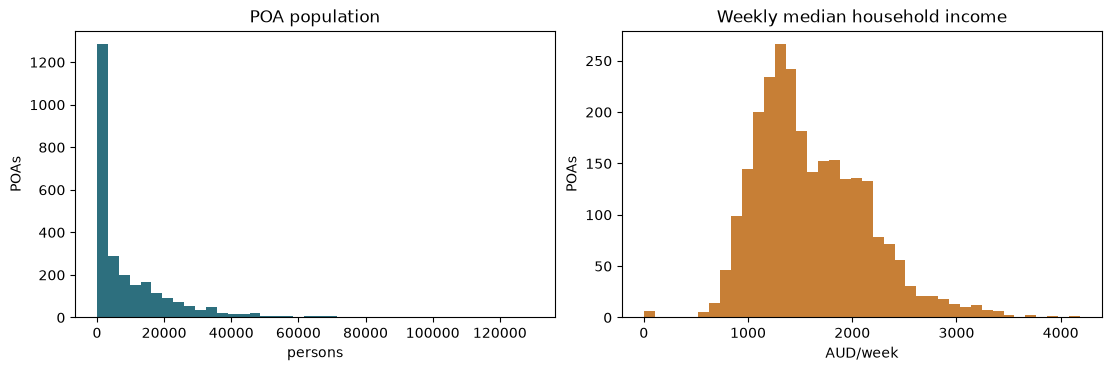

In [4]:
outliers = pd.read_csv('../results/outlier_summary.csv')
display(outliers)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout='constrained')
axes[0].hist(features['census_population'].dropna(), bins=40, color='#2d6f7e')
axes[0].set(title='POA population', xlabel='persons', ylabel='POAs')
axes[1].hist(features['census_median_household_income_weekly'].dropna(), bins=40, color='#c77f36')
axes[1].set(title='Weekly median household income', xlabel='AUD/week', ylabel='POAs')
plt.show()

## Downstream join contract

Join curated transaction consumer_postcode to census_clean postcode using a many-to-one LEFT JOIN. Preserve every transaction, retain match status, and do not convert unmatched Census values to zero. POAs approximate postcode geography and Census values are 2021 area context rather than individual attributes or causal effects.

## Consumer postcode coverage

Actual coverage against the supplied consumer table. Unmatched consumers are retained and Census features remain missing, not zero. This is consumer-row coverage, not transaction coverage.

In [5]:
coverage = pd.read_csv('../results/consumer_join_coverage.csv')
display(coverage)
matched = coverage[(coverage['scope'] == 'consumer_rows') & (coverage['metric'] == 'matched')].iloc[0]
print(f"{int(matched['rows']):,} / {int(matched['denominator']):,} consumers matched ({matched['rate']:.2%})")
display(pd.read_csv('../results/consumer_feature_missingness.csv'))

416,818 / 499,999 consumers matched (83.36%)


,scope,metric,rows,denominator,rate
0,consumer_rows,matched,416818,499999,0.833638
1,consumer_rows,postcode_not_in_census,83181,499999,0.166362
2,consumer_rows,special_geography,0,499999,0.000000
3,consumer_rows,missing_or_invalid_postcode,0,499999,0.000000
4,distinct_valid_postcodes,matched,2640,3167,0.833596


,field,all_consumer_missing,matched_consumer_missing,unmatched_consumer_rows,all_consumer_rows
0,census_population,83181,0,83181,499999
1,census_age_20_24,83181,0,83181,499999
2,census_age_25_34,83181,0,83181,499999
3,census_age_35_44,83181,0,83181,499999
4,census_median_age,83340,159,83181,499999
5,census_median_household_income_weekly,83181,0,83181,499999
6,census_avg_household_size,83799,618,83181,499999
7,census_couple_no_children_families,83181,0,83181,499999
8,census_couple_with_children_families,83181,0,83181,499999
9,census_single_parent_families,83181,0,83181,499999
